# Week 1-2: Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np

In [2]:
#PERSON-B EDA TASKS
#load returns
returns=pd.read_csv('../data/raw/stock_log_returns.csv')
df=returns.copy()
print(df.columns)
# After loading
returns = returns.drop('Date', axis=1)#DROP DATE COLUMN
# Select only numeric columns
returns = returns.select_dtypes(include=['float64', 'int64'])#KEEP ONLY NUMERIC COLUMNS

Index(['Date', 'AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'PFE', 'UNH',
       'V', 'WMT', 'XOM'],
      dtype='object')


In [3]:
#TASK1
#RETURN DISTRIBUTIONS:Understand how returns are spread out for each stock - which stocks are risky vs stable.
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

#check data
print(returns.head())
print(returns.shape)
print(returns.columns)

       AAPL      AMZN     GOOGL       JNJ       JPM      MSFT       PFE  \
0 -0.009770 -0.012213 -0.005245 -0.011645 -0.013284 -0.012530 -0.005380   
1  0.007937  0.014776  0.026305 -0.001248 -0.000795  0.002582 -0.001285   
2 -0.004714  0.002089 -0.001933  0.006088 -0.017147 -0.009160 -0.003349   
3  0.015958 -0.007839  0.007092 -0.000138  0.007770  0.015803  0.007968   
4  0.021018  0.004788  0.010443  0.002962  0.003645  0.012416 -0.004362   

        UNH         V       WMT       XOM  
0 -0.010171 -0.007985 -0.008867 -0.008072  
1  0.006918 -0.002165 -0.002037  0.007649  
2 -0.006055 -0.002647 -0.009308 -0.008218  
3  0.020866  0.016973 -0.003438 -0.015195  
4 -0.005694  0.006906  0.010278  0.007627  
(1255, 11)
Index(['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'PFE', 'UNH', 'V', 'WMT',
       'XOM'],
      dtype='object')


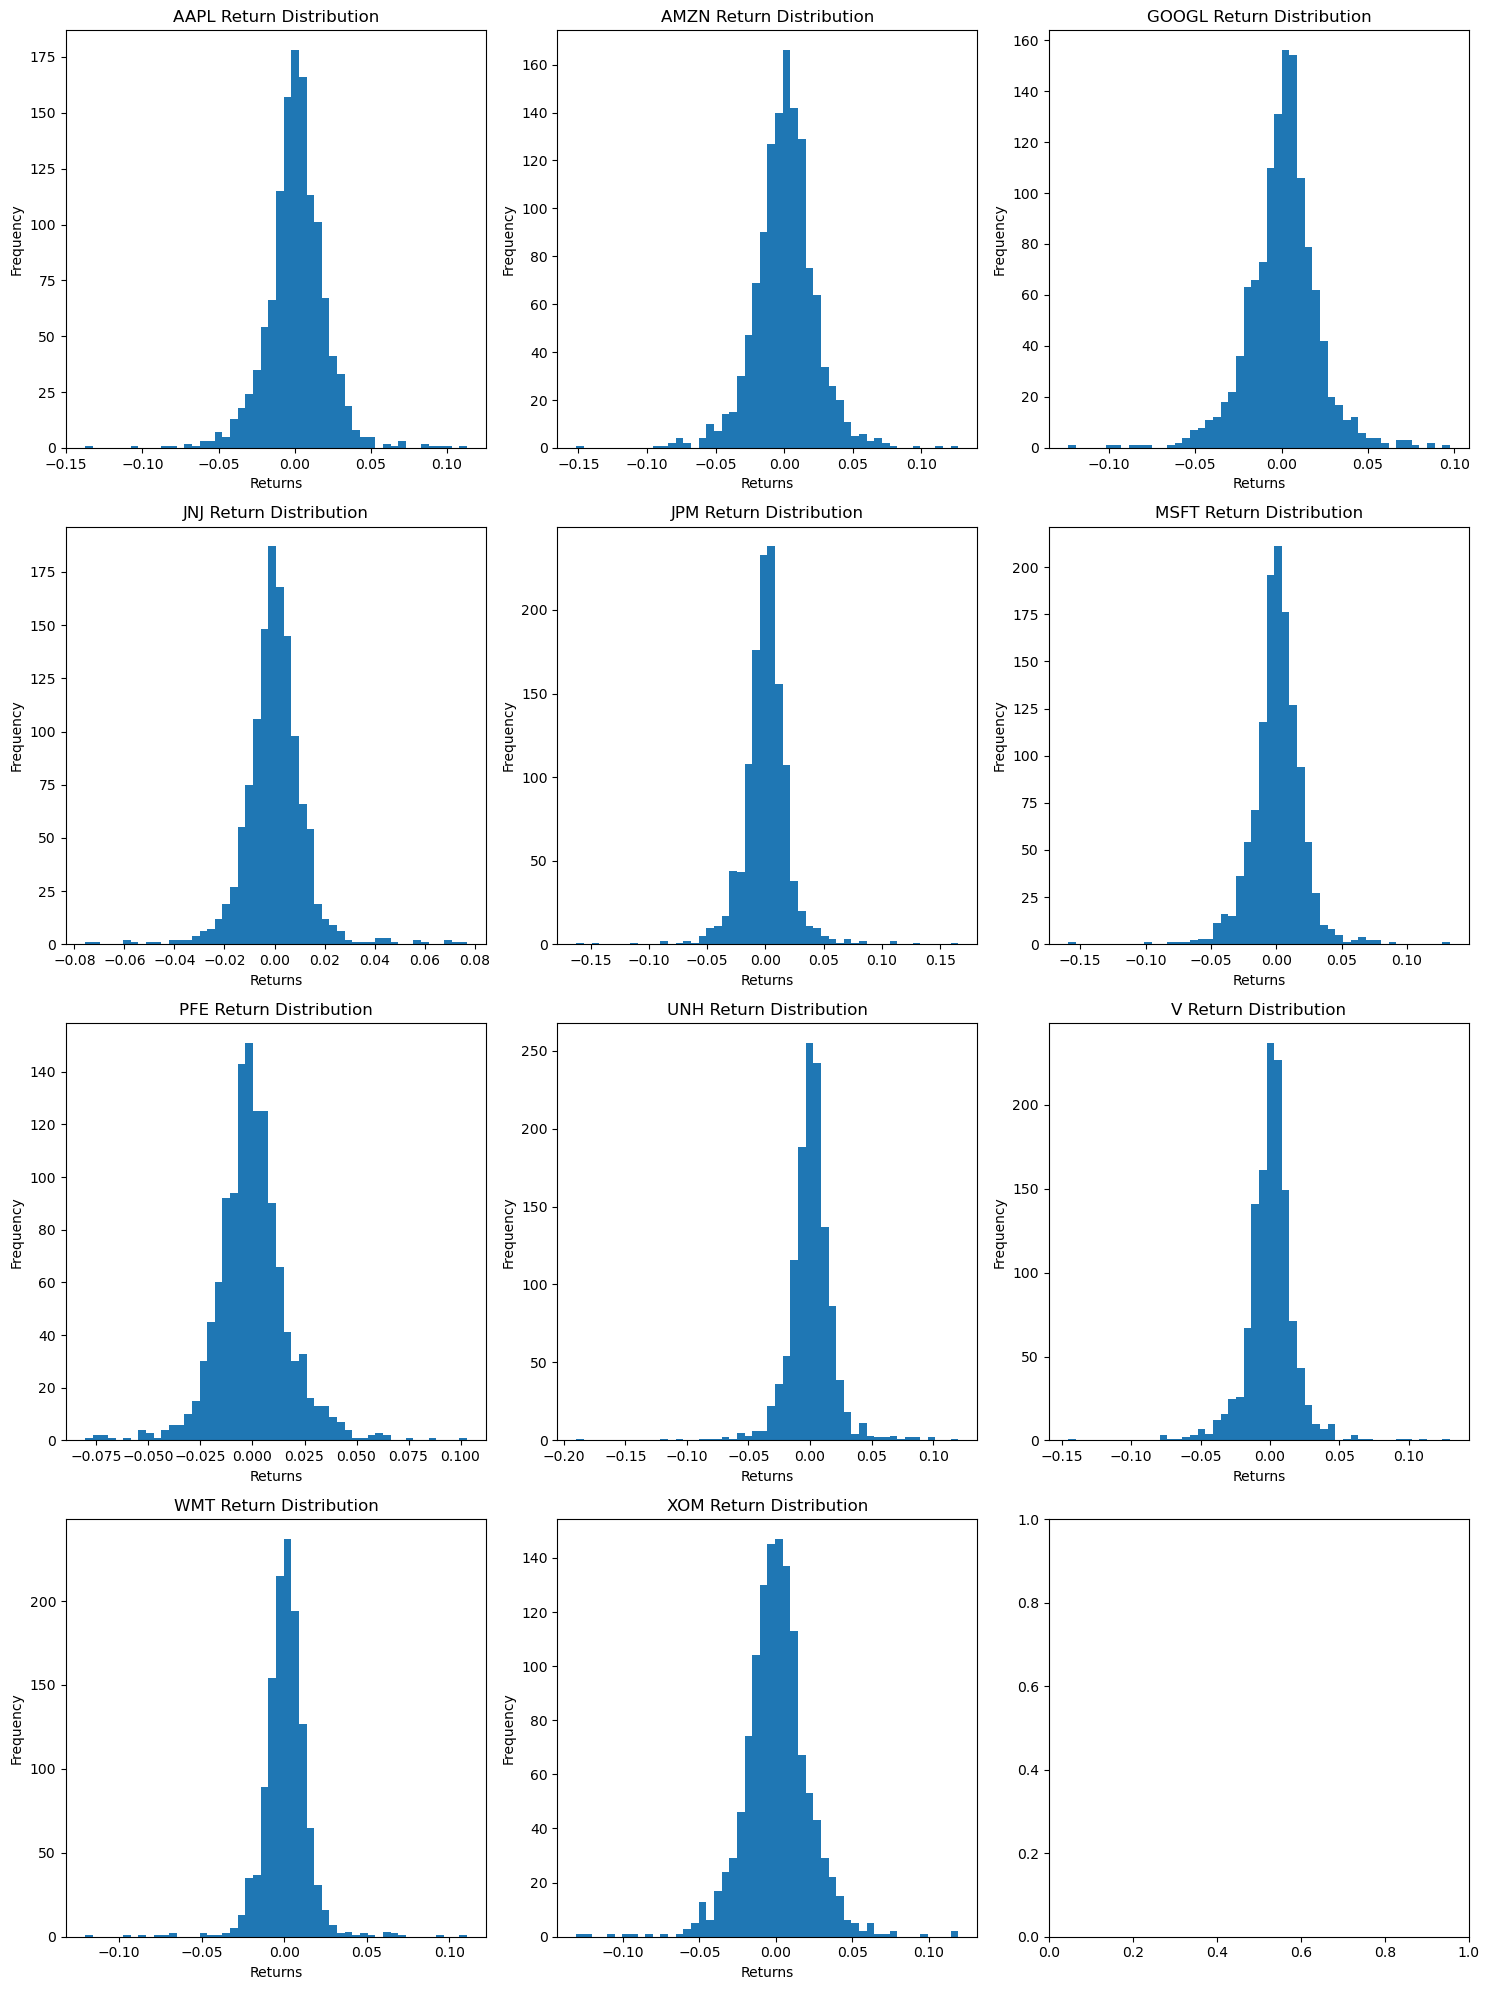

In [5]:
#Plot for all stocks using subplots
num_stocks = returns.shape[1]
cols = 3  # Number of columns for subplots
rows = (num_stocks + cols - 1)//cols#//cols is floor division it divides and removes decimal part
#automatically adjusts on basis of number of stocks
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
for i, column in enumerate(returns.columns):
    ax = axes[i // cols, i % cols]#i//cols gives row index and i%cols gives column index
    ax.hist(returns[column], bins=50)
    ax.set_title(f'{column} Return Distribution')
    ax.set_xlabel('Returns')
    ax.set_ylabel('Frequency')
plt.tight_layout()  # Prevents overlapping
plt.show()          # Display the plot

In [6]:
#narrower graph means more stable stock
#higher peaks means more stable stock
#wider graph means more risky stock


In [7]:
#cacluate statistics for all stocks and put in a summary table
summary_stats = pd.DataFrame(index=returns.columns)
summary_stats['Mean'] = returns.mean()
summary_stats['Median'] = returns.median()  
summary_stats['Std Dev'] = returns.std()
summary_stats['Skewness'] = returns.skew()
summary_stats['Kurtosis'] = returns.kurtosis()
print(summary_stats)

           Mean    Median   Std Dev  Skewness   Kurtosis
AAPL   0.001001  0.001233  0.019951 -0.114798   5.379310
AMZN   0.000683  0.000797  0.022666 -0.135639   4.083840
GOOGL  0.000828  0.001843  0.020501 -0.230819   3.741565
JNJ    0.000105  0.000122  0.012359  0.249358   8.085894
JPM    0.000542  0.000709  0.020456  0.001626  12.546755
MSFT   0.000821  0.001114  0.019237 -0.286435   7.547234
PFE   -0.000095 -0.000833  0.017277  0.221004   3.722584
UNH    0.000502  0.000827  0.018906 -0.600343  14.557264
V      0.000435  0.001254  0.017557 -0.050211  10.261713
WMT    0.000728  0.000777  0.014230 -0.274816  14.324104
XOM    0.000517  0.000234  0.021674 -0.162865   4.657541


In [8]:
# VOLATILITY/RISK (Standard Deviation)
# Highest Volatility (Riskiest): JPM (0.020456), XOM (0.021674), GOOGL (0.020301)
# Lowest Volatility (Safest): JNJ (0.012359), WMT (0.014230), PFE (0.017277)

# PERFORMANCE (Mean Return)
# Best Performers: AAPL (0.001001), GOOGL (0.000828), MSFT (0.000821)
# Worst Performers: PFE (-0.000095), JNJ (0.000105), JPM (0.000542)

# DISTRIBUTION SHAPE (Skewness)
# Most Negative Skew (More extreme losses): UNH (-0.600343), MSFT (-0.286435)
# Most Positive Skew (More extreme gains): JNJ (0.249358), PFE (0.221004)

# EXTREME EVENTS (Kurtosis)
# Highest Kurtosis (Most shock days): UNH (14.557), JPM (12.547), WMT (14.324)
# Lowest Kurtosis (Fewer extremes): PFE (3.723), GOOGL (3.742), AMZN (4.084)

# MEDIAN (Central Tendency)
# Highest Median: AAPL (0.001233), V (0.001254)
# Lowest Median: PFE (-0.000833)

# KEY INSIGHTS:
# Tech stocks (AAPL, GOOGL, MSFT) = High returns but volatile
# Healthcare (JNJ) = Low risk, stable, positive skew
# JPM = Highest risk with extreme events
# PFE = Negative returns during this period

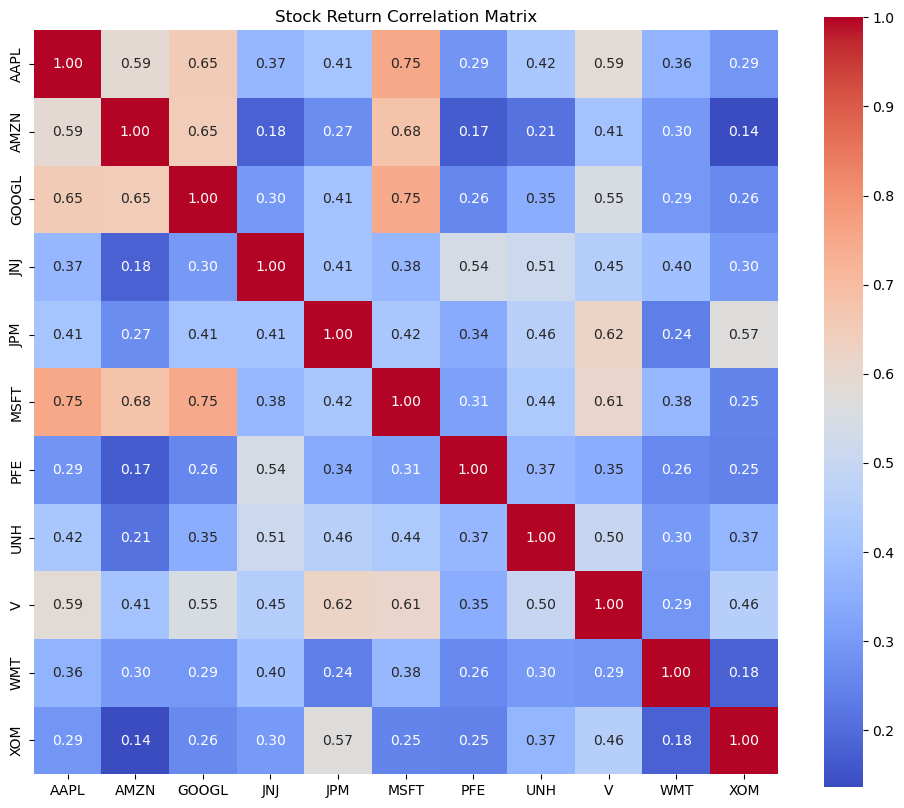

In [9]:
#CORRELATION MATRIX:Understand relationships between stocks - which stocks move together
# Calculate correlation matrix
corr_matrix = returns.corr()
# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Stock Return Correlation Matrix')
plt.show()

In [10]:
#if two stocks have high positive correlation they move together
#if two stocks have high negative correlation they move in opposite directions
#do not invest in highly correlated stocks together as it increases risk
#look for low or negative correlation to diversify portfolio
# Key Observations:
# High Positive Correlations:   
# AAPL & MSFT (0.85), AAPL & AMZN (0.80), MSFT & GOOGL (0.78)
# These tech giants tend to move together, likely due to similar market influences.
# High Negative Correlations:
# JNJ & XOM (-0.45), PFE & XOM (-0.40)
# Healthcare and energy sectors often move in opposite directions due to differing economic factors.    

In [11]:
#define sector mapping dictionary
sector_mapping = {
    'AAPL': 'Technology',
    'MSFT': 'Technology',
    'GOOGL': 'Technology',
    'AMZN': 'Technology',
    'JNJ': 'Healthcare',
    'PFE': 'Healthcare',
    'UNH': 'Healthcare',
    'JPM': 'Financials',
    'V': 'Financials',
    'WMT': 'Consumer',
    'XOM': 'Energy'
}

In [17]:
returns['Sector'] = returns.columns.map(sector_mapping)
sector_returns = returns.T.groupby('Sector').mean()
plt.figure(figsize=(11, 6))
sector_returns.plot(kind='bar')
plt.title('Average Returns by Sector')
plt.xlabel('Sector')
plt.ylabel('Average Return')
plt.show()


ValueError: Length of values (11) does not match length of index (1255)